[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/PSets/PSet0_Prerequisites.ipynb)

# LEARNING OBJECTIVE

After exploring this notebook, you will be able to use symbolic computing to _check_ the vector calculus, linear algebra, and ODE manipulations from the Module 0 problem set on prerequisites. Along the way, you will see that the computer is good at the algebra but that _you_ still have to set up the problem, choose the assumptions, and interpret the answer.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial solution written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# HOW TO USE THIS NOTEBOOK

⚠️ **This is optional/enrichment material.** The Module 0 problem set asks you to do all of this _by hand_, and that is the point: the process matters more than the answer. What follows is how _I_ check my own work: a second, independent path to the same expressions.

A few habits worth stealing:

* Write the ODE/matrix/field down in the code exactly as you wrote it on paper, then print it back out and _read it_ before solving anything. Most "the computer got it wrong" moments are really "I typed a different problem" moments.
* Tell the symbolic engine what you know (`positive=True`, `real=True`, ...). It cannot simplify $\sqrt{x^2}$ to $x$ unless you tell it that $x>0$, and physics is usually full of such information.
* When the computer's answer looks different from yours, it is often the _same_ answer in disguise (a different but equally valid basis, a rescaled eigenvector, a logarithm combined differently). Learning to recognize this is a skill in itself.

Each problem below is numbered as in the problem set. The parts asking you to _classify_ an ODE or to _sketch_ something are discussed where a computation can support them; the purely conceptual parts are left to you.

Note that we reuse short symbol names such as `x`, `y`, `t`, and `k` from problem to problem, redefining them as we go, so run the cells in order.

# PROBLEM 1: DIV, GRAD, CURL AND ALL THAT

## Problem statement

Assuming a 3D Cartesian coordinate system $(x,y,z)$ with unit coordinate vectors $\underline{\hat{\imath}}$, $\underline{\hat{\jmath}}$, $\underline{\hat{k}}$:

(a) Compute $\nabla\cdot\big(axy\,\underline{\hat{\imath}}+bxz\,\underline{\hat{\jmath}}+0\,\underline{\hat{k}}\big)$. What is the operation $\nabla\cdot(\cdots)$ called?

(b) Compute $\nabla(xyt+z^2)$. What is the operation $\nabla(\cdots)$ called?

(c) Compute $\nabla\times\big(f(x)\,\underline{\hat{k}}\big)$, where $f(x)$ is any function of $x$. What is the operation $\nabla\times(\cdots)$ called?

## Solution

We set up a Cartesian coordinate system using SymPy's [vector capabilities](https://docs.sympy.org/latest/modules/vector/fields.html), which is the same setup used in the [kinematics and the material derivative](../kinematics_material_derivative.ipynb) notebook.

In [2]:
C = CoordSys3D('C')

# C.x, C.y, C.z are the coordinates
# C.i, C.j, C.k are the unit vectors

### (a)

The operation $\nabla\cdot(\cdots)$ is the **divergence**. Here, $a$ and $b$ are constants.

In [3]:
a, b = sp.symbols('a b')

v = a*C.x*C.y * C.i + b*C.x*C.z * C.j + 0 * C.k
v  # to print it, so we can check we typed in the right vector field

Now we just ask for the divergence.

In [4]:
divergence(v)

So $\nabla\cdot\underline{v} = ay$: the $bxz\,\underline{\hat{\jmath}}$ term contributes nothing because $\partial(bxz)/\partial y=0$.

Because this vector field has a nonzero divergence, it could _not_ describe the velocity field of an incompressible flow, except on the plane $y=0$. Keep this in mind; we will use $\nabla\cdot\underline{v}=0$ constantly later in the course.

### (b)

The operation $\nabla(\cdots)$ is the **gradient**. The subtle point here is that $t$ is _independent_ of $x$, $y$, $z$, so it acts as a constant under $\nabla$. In the code, that distinction is automatic: `t` is a plain SymPy symbol, whereas `C.x`, `C.y`, `C.z` are the coordinates of the coordinate system, and `gradient` only differentiates with respect to those.

In [5]:
t = sp.symbols('t')

phi = C.x*C.y*t + C.z**2
phi  # to print it, so we can check it

In [6]:
gradient(phi)

So $\nabla(xyt+z^2) = yt\,\underline{\hat{\imath}}+xt\,\underline{\hat{\jmath}}+2z\,\underline{\hat{k}}$, and note that the gradient of a scalar is a _vector_.

### (c)

The operation $\nabla\times(\cdots)$ is the **curl**. Since $f(x)$ is _any_ function of $x$, we let SymPy carry it along as an undefined function, `sp.Function('f')`, rather than committing to a specific one.

In [7]:
f = sp.Function('f')

w = 0 * C.i + 0 * C.j + f(C.x) * C.k
w  # to print it, so we can check it

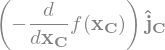

In [8]:
curl(w)

So $\nabla\times\big(f(x)\,\underline{\hat{k}}\big) = -f'(x)\,\underline{\hat{\jmath}}$, where we may write $f'(x)=df/dx$ without confusion because $f$ depends on $x$ only. The determinant trick you used by hand and the code agree, including the pesky minus sign on the $\underline{\hat{\jmath}}$ component. 🙂

**On your own:** a vector field of this type, $f(y)\,\underline{\hat{\imath}}$, is exactly what a unidirectional shear flow looks like, and its curl is the _vorticity_. Try `curl(f(C.y) * C.i)` and see which component survives.

# PROBLEM 2: MULTIDIMENSIONAL CHAIN RULE

## Problem statement

(a) Compute $\frac{df}{dt}$ of the function $f\big(x(t),y(t),z(t)\big)$, for any set of functions $\{x(t),y(t),z(t)\}$.

(b) Compute $\frac{df}{dt}$ of the function $f\big(t,\xi(t)\big)$ if $\xi(t) = \frac{x}{t}$.

## Solution

### (a)

The whole point of this part is that _nothing_ is specified: $f$ is an arbitrary function of three arbitrary functions of $t$. So we declare all of them as undefined functions and just ask for the derivative.

In [9]:
t = sp.symbols('t')
x = sp.Function('x')(t)
y = sp.Function('y')(t)
z = sp.Function('z')(t)

f = sp.Function('f')(x, y, z)
f  # to print it, so we can check it

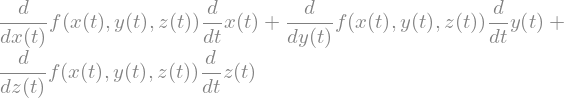

In [10]:
f.diff(t)

That is the chain rule,
$$\frac{df}{dt} = \frac{\partial f}{\partial x}\frac{dx}{dt} + \frac{\partial f}{\partial y}\frac{dy}{dt} + \frac{\partial f}{\partial z}\frac{dz}{dt},$$
just written in SymPy's more pedantic notation: it prints $\frac{\partial}{\partial x(t)}$ because, to SymPy, the first slot of $f$ literally _is_ the object $x(t)$.

If $\underline{v} = \frac{dx}{dt}\underline{\hat{\imath}} + \frac{dy}{dt}\underline{\hat{\jmath}} + \frac{dz}{dt}\underline{\hat{k}}$ is a velocity field, this is $\frac{df}{dt} = \underline{v}\cdot\nabla f$, a special case (with $\partial f/\partial t=0$) of the material derivative that the whole course is built on. See the [kinematics and the material derivative](../kinematics_material_derivative.ipynb) notebook for where this goes next.

### (b)

Now $f$ depends on $t$ _both_ directly (first slot) and through $\xi(t)$ (second slot). It pays to do this in two steps: first get the chain rule for a generic $\xi(t)$, then substitute the given $\xi = x/t$.

In [11]:
xi = sp.Function('xi')(t)

f = sp.Function('f')(t, xi)
f  # to print it, so we can check it

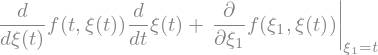

In [12]:
chain_rule = f.diff(t)
chain_rule

Read this as
$$\frac{df}{dt} = \frac{\partial f}{\partial t}\underbrace{\frac{dt}{dt}}_{=1} + \frac{\partial f}{\partial \xi}\frac{d\xi}{dt}.$$
The odd-looking $\left.\frac{\partial}{\partial \xi_1}f(\xi_1,\xi(t))\right|_{\xi_1=t}$ is SymPy being careful: it means "differentiate $f$ with respect to its _first_ slot, then set that slot back to $t$," which is exactly what we mean by $\partial f/\partial t$ at fixed $\xi$. This kind of bookkeeping is worth mimicking on paper when you get confused about which "$t$" you are differentiating.

Now substitute the given $\xi(t) = x/t$, for which $\frac{d\xi}{dt} = -\frac{x}{t^2}$.

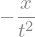

In [13]:
xs = sp.symbols('x')  # here x is an independent variable, not the function x(t) of part (a)

dxi_dt = sp.diff(xs/t, t)
dxi_dt

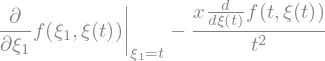

In [14]:
# replace every "d(xi)/dt" in the chain rule above by the -x/t^2 we just computed
chain_rule.subs(sp.Derivative(xi, t), dxi_dt)

So
$$\boxed{\frac{df}{dt} = \frac{\partial f}{\partial t} - \frac{x}{t^2}\frac{\partial f}{\partial \xi}}$$
as obtained by hand. The combination $\xi = x/t$ is not an arbitrary choice, by the way: it is a _similarity variable_, and this exact chain rule is the first step in solving [Stokes' first problem](../Stokes_1st_problem.ipynb) and the [decay of an ideal vortex](../decay_ideal_vortex.ipynb) later in the course.

# PROBLEM 3: "UNDOING" PARTIAL DERIVATIVES

## Problem statement

Your experiment has measured a spatially variable pressure gradient field $\nabla p(x,y) = -k x \,\underline{\hat{\imath}} + ky \,\underline{\hat{\jmath}}$, $k=1~\mathrm{Pa/m^2}$, and $p(0,0) = 1~\mathrm{Pa}$. Find $p(x,y)$.

## Solution

First, a sanity check that is _not_ asked for but is free: a vector field can only be the gradient of a scalar (that is, be _conservative_) if its curl vanishes. If the curl were nonzero, no $p(x,y)$ could exist and we would go back to the lab.

In [15]:
k = sp.symbols('k', positive=True)

gradp = -k*C.x * C.i + k*C.y * C.j + 0 * C.k
gradp  # to print it, so we can check it

In [16]:
curl(gradp)  # must vanish for a p(x,y) to exist

### Approach 1: undo the partial derivatives one at a time

Integrate $\partial p/\partial x = -kx$ with respect to $x$. The "constant of integration" is an arbitrary function of $y$, because $\partial/\partial x$ annihilates any function of $y$ &mdash; **this is the important point of this problem**, and it is one thing SymPy will _not_ remind you about: `sp.integrate` silently drops it.

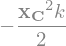

In [17]:
p_partial = sp.integrate(gradp & C.i, C.x)  # & is one way to form a dot product in SymPy
p_partial

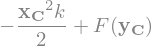

In [18]:
F = sp.Function('F')

p = p_partial + F(C.y)  # we have to add the arbitrary function of y ourselves!
p

Next, take $\partial/\partial y$ of what we have so far. Since the first term does not involve $y$, all that survives is $F'(y)$.

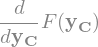

In [19]:
sp.diff(p, C.y)

But the experiment tells us that $\partial p/\partial y = ky$. So $F'(y) = ky$, and we integrate that to get $F(y)$. This time the constant of integration really is a constant.

In [20]:
dF_dy = gradp & C.j  # the measured y-component, = k*y
dF_dy

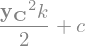

In [21]:
c = sp.symbols('c')  # the genuine constant of integration, at last

F_of_y = sp.integrate(dF_dy, C.y) + c
F_of_y

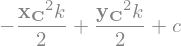

In [22]:
p = p_partial + F_of_y
p

Finally, pin down $c$ from the measurement $p(0,0)=1~\mathrm{Pa}$. First evaluate our $p$ at the origin:

In [23]:
p_at_origin = p.subs({C.x: 0, C.y: 0})
p_at_origin

and then set that equal to the measured $1~\mathrm{Pa}$ and solve for $c$. Note that `sp.solve` returns a _list_ of solutions (here, just one), so we take its first entry with `[0]`.

In [24]:
c_val = sp.solve(sp.Eq(p_at_origin, 1), c)
c_val

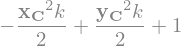

In [25]:
p = p.subs(c, c_val[0])
p

So
$$\boxed{p(x,y) = -\frac{kx^2}{2}+\frac{ky^2}{2}+1}$$
with units implied ($k$ in $\mathrm{Pa/m^2}$, $p$ in $\mathrm{Pa}$). In this class, if we must use units, they will always be [SI units](https://en.wikipedia.org/wiki/SI_derived_unit).

### Approach 2: the fundamental theorem of line integrals

Because $\nabla p$ is conservative, the [fundamental theorem of line integrals](https://math.libretexts.org/@go/page/4833) gets us there with only _definite_ integrals, so there is no constant (or function!) of integration to chase:
$$\int_{p(0,0)}^{p(x,y)} dp = \int_0^x \frac{\partial p}{\partial \tilde{x}}\,d\tilde{x} + \int_0^y \frac{\partial p}{\partial \tilde{y}}\,d\tilde{y},$$
with $\tilde{x}$, $\tilde{y}$ dummy integration variables.

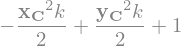

In [26]:
xtilde, ytilde = sp.symbols('xtilde ytilde')

p_line = 1 + sp.integrate((gradp & C.i).subs(C.x, xtilde), (xtilde, 0, C.x)) \
           + sp.integrate((gradp & C.j).subs(C.y, ytilde), (ytilde, 0, C.y))
p_line

In [27]:
# do the two approaches agree?
sp.simplify(p - p_line) == 0

True

Whichever way we got it, we should verify that our answer reproduces the data we were given, by taking its gradient and subtracting the measured field.

In [28]:
sp.simplify(gradient(p) - gradp)  # must vanish

### What does this pressure field look like?

An expression is one thing; a picture is another. With $k=1$, the isobars (contours of constant $p$) are hyperbolae and the pressure field is a **saddle**: pressure falls off along $x$ and rises along $y$. Overlaying $\nabla p$ as arrows shows the two facts worth remembering: the gradient is everywhere _perpendicular_ to the isobars, and it points toward _increasing_ $p$ (so a fluid, pushed by $-\nabla p$, would accelerate the other way).

In [29]:
# turn the symbolic expressions into numerical functions of (x, y), with k = 1
p_num = sp.lambdify((C.x, C.y), p.subs(k, 1))
dpdx_num = sp.lambdify((C.x, C.y), (gradp & C.i).subs(k, 1))
dpdy_num = sp.lambdify((C.x, C.y), (gradp & C.j).subs(k, 1))

Then evaluate them on a grid of points covering the region we want to see, and plot.

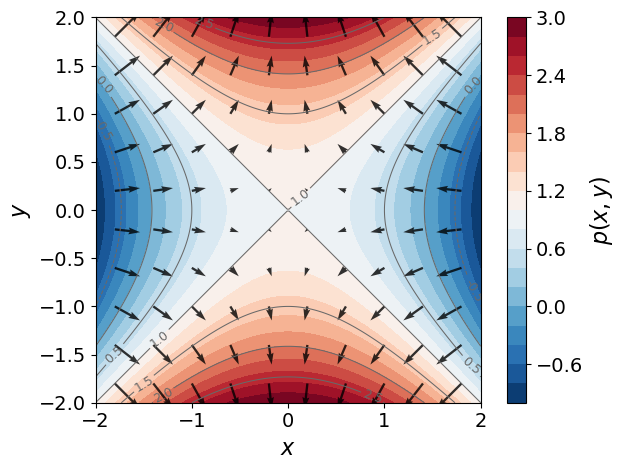

In [30]:
# a fine grid for the contours, and a coarse one so the arrows don't crowd
xplot, yplot = np.meshgrid(np.linspace(-2, 2, num=200), np.linspace(-2, 2, num=200))
xquiv, yquiv = np.meshgrid(np.linspace(-1.8, 1.8, num=10), np.linspace(-1.8, 1.8, num=10))

pplot = p_num(xplot, yplot)

fig, ax = plt.subplots(tight_layout=True)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_aspect('equal')

# isobars: filled for the overall trend, labeled lines for specific values of p
filled = ax.contourf(xplot, yplot, pplot, levels=21, cmap='RdBu_r')
lines = ax.contour(xplot, yplot, pplot, levels=np.arange(-1, 3.1, 0.5),
                   colors='dimgray', linewidths=0.75)
ax.clabel(lines, inline=True, fontsize=9, fmt='%.1f')

# the measured pressure gradient field, as arrows
ax.quiver(xquiv, yquiv, dpdx_num(xquiv, yquiv), dpdy_num(xquiv, yquiv),
          color='black', alpha=0.8)

fig.colorbar(filled, ax=ax, label='$p(x,y)$')
plt.show()

Two features of the plot are worth pointing out, because both are consequences of the formula we derived and both are easy to check by hand:

* The arrows shrink to nothing at the origin, since $\nabla p = \underline{0}$ there. That is the saddle point &mdash; not a maximum or a minimum of $p$.
* The isobar labeled $1.0$ is a pair of _straight_ lines, the diagonals $y=\pm x$. Along them $-kx^2/2+ky^2/2=0$, so $p=p(0,0)=1~\mathrm{Pa}$ exactly, no matter how far out we go.

# PROBLEM 4: GAUSSIAN ELIMINATION, RREF, AND THE NULLSPACE

## Problem statement

Consider the rectangular matrix
$$
\underline{\underline{A}} =
\begin{bmatrix}
1 & 2 & -1 & 0 & 3 \\
0 & 1 & 1 & -1 & 2 \\
2 & 5 & 0 & -1 & 8
\end{bmatrix}.
$$

(a) Use Gaussian elimination to compute a row echelon form and the reduced row echelon form (RREF) of $\underline{\underline{A}}$.

(b) Determine $\mathrm{rank}(\underline{\underline{A}})$ and $\mathrm{nullity}(\underline{\underline{A}})$.

(c) Find a basis for the nullspace of the homogeneous system $\underline{\underline{A}}\,\underline{x}=\underline{0}$, and verify your basis vectors by direct substitution.

## Solution

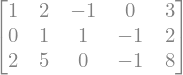

In [31]:
A = sp.Matrix([[1, 2, -1, 0, 3],
               [0, 1, 1, -1, 2],
               [2, 5, 0, -1, 8]])
A

### (a)

It is tempting to jump straight to `A.rref()`, but the _process_ is the point here, so let's first reproduce the elementary row operations we did by hand. SymPy exposes them through [`elementary_row_op`](https://docs.sympy.org/latest/modules/matrices/matrices.html#sympy.matrices.matrixbase.MatrixBase.elementary_row_op), where `'n->n+km'` means $R_n \leftarrow R_n + k R_m$ (and remember Python indexes from 0, so our $R_3$ is `row=2`).

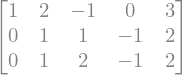

In [32]:
# R3 <- R3 - 2*R1, to kill the leading 2 in the third row
REF = A.elementary_row_op('n->n+km', row=2, k=-2, row2=0)
REF

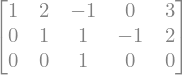

In [33]:
# R3 <- R3 - R2, to kill the 1 that is now under the second pivot
REF = REF.elementary_row_op('n->n+km', row=2, k=-1, row2=1)
REF

Two row operations were enough to reach a row echelon form: nonzero rows are stacked on top, and each pivot sits strictly to the right of the pivot above it. A row echelon form is _not_ unique: continuing to clean up above the pivots (as in the by-hand solution) gives a different, equally valid echelon form.

The RREF _is_ unique, and this is where we happily let the computer do the arithmetic. It returns both the reduced matrix and the tuple of pivot columns.

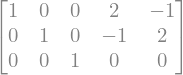

In [34]:
RREF, pivots = A.rref()
RREF

In [35]:
pivots  # which columns hold the pivots (again, indexed from 0)

### (b)

The rank is the number of pivots, and the [rank&ndash;nullity theorem](https://youtu.be/nHlE7EgJFds?t=705) then fixes the nullity:
$$\mathrm{nullity}(\underline{\underline{A}}) = \#\ \text{columns} - \mathrm{rank}(\underline{\underline{A}}).$$

In [36]:
A.rank()  # equal to the number of pivots we found above

In [37]:
A.cols - A.rank()  # the nullity

So $\mathrm{rank}(\underline{\underline{A}})=3$ and $\mathrm{nullity}(\underline{\underline{A}})=5-3=2$.

Since $\underline{\underline{A}}$ has only 3 rows, a rank of 3 is the largest it could possibly be: none of the three equations was redundant, which is why elimination left us three pivots. But there are 5 unknowns and only 3 independent equations, so 2 of the unknowns can be chosen freely, and that is the 2 that `nullity` is counting.

### (c)

Columns 4 and 5 (indices 3 and 4) are the non-pivot columns, so $x_4$ and $x_5$ are the free variables. Reading the RREF row by row gives $x_1=-2x_4+x_5$, $x_2=x_4-2x_5$, and $x_3=0$. SymPy's `nullspace` does that back-substitution for us, returning one basis vector per free variable.

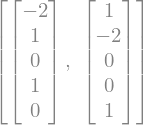

In [38]:
nullA = A.nullspace()
nullA

These are exactly the two vectors we found by hand (each is what you get by setting one free variable to 1 and the other to 0). `nullspace` returns them in a list, so let's give them names.

In [39]:
# remember Python indexes start at 0
v1 = nullA[0]
v2 = nullA[1]

Now verify by direct substitution, as the problem asks: both products must be the zero vector.

In [40]:
A*v1

In [41]:
A*v2

Finally, the _general_ solution of $\underline{\underline{A}}\,\underline{x}=\underline{0}$ is any linear combination of the two basis vectors, with the free variables playing the role of the arbitrary coefficients.

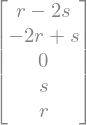

In [42]:
s, r = sp.symbols('s r')  # arbitrary coefficients (x_4 = s and x_5 = r)

x_general = s*v1 + r*v2
x_general

In [43]:
A*x_general  # must vanish for all s and r

**Why we care:** this is not linear algebra for its own sake. In [dimensional analysis](../dimensional_analysis.ipynb), the matrix is the _dimensional matrix_, its nullspace vectors _are_ the dimensionless $\Pi$ groups, and the rank&ndash;nullity theorem _is_ Buckingham's $\Pi$ theorem. The nullity you just computed is the number of dimensionless groups in a problem.

# PROBLEM 5: EIGENVALUES/EIGENVECTORS OF A SINGULAR SYMMETRIC MATRIX

## Problem statement

Consider the symmetric matrix
$$
\underline{\underline{T}} =
\begin{bmatrix}
4 & 2 & 0 \\
2 & 1 & 0 \\
0 & 0 & -3
\end{bmatrix}.
$$

(a) Compute $\det(\underline{\underline{T}}-\lambda\underline{\underline{I}})$ and find the eigenvalues $\lambda$.

(b) Focus on the singular mode $\lambda=0$. Solve $(\underline{\underline{T}}-0\,\underline{\underline{I}})\underline{v}=\underline{0}$ to find the eigenspace, a basis for it and its dimension.

## Solution

### (a)

Let's build the characteristic polynomial the same way we would on paper: form $\underline{\underline{T}}-\lambda\underline{\underline{I}}$, take its determinant, and factor. (In SymPy, the symbol is spelled `lamda`, without the "b", because `lambda` is a reserved Python keyword. It still typesets as $\lambda$.)

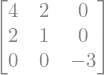

In [44]:
T = sp.Matrix([[4, 2, 0],
               [2, 1, 0],
               [0, 0, -3]])
T

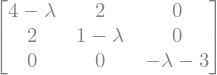

In [45]:
lam = sp.symbols('lamda')

char_matrix = T - lam*sp.eye(3)
char_matrix

In [46]:
char_poly = char_matrix.det()
char_poly

In [47]:
sp.factor(char_poly)  # factored, the roots are obvious

In [48]:
sp.solve(sp.Eq(char_poly, 0), lam)

So $\lambda_1=0$, $\lambda_2=5$, $\lambda_3=-3$. Of course, there is also a one-liner that skips straight to the answer, returning a dictionary of `eigenvalue: multiplicity` pairs.

In [49]:
T.eigenvals()

### (b)

The eigenspace for $\lambda=0$ is the set of $\underline{v}$ with $\underline{\underline{T}}\,\underline{v}=\underline{0}$. That is, it is precisely the _nullspace_ of $\underline{\underline{T}}$, which is why $\lambda=0$ and singularity are the same statement. We already know how to get a nullspace from Problem 4.

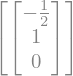

In [50]:
T.nullspace()  # the eigenspace for lambda = 0

One basis vector, so the eigenspace has dimension 1. SymPy hands us $[-1/2,\ 1,\ 0]^\top$ while by hand we wrote $[1,\ -2,\ 0]^\top$; these differ by a factor of $-1/2$ and therefore span the same line. **Eigenvectors are only defined up to a multiplicative constant**, so "different" answers here are the same answer.

For all the eigenvalues at once, `eigenvects` returns triples of (eigenvalue, multiplicity, basis of the eigenspace).

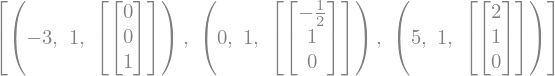

In [51]:
T.eigenvects()

### Extra: why the zero eigenvalue makes $\underline{\underline{T}}$ singular

Two identities are worth checking, because they let you catch algebra mistakes in seconds: the determinant is the _product_ of the eigenvalues, and the trace is their _sum_.

In [52]:
lam1, lam2, lam3 = 0, 5, -3  # the eigenvalues we found above

T.det(), lam1*lam2*lam3  # determinant vs. product of the eigenvalues

In [53]:
T.trace(), lam1 + lam2 + lam3  # trace vs. sum of the eigenvalues

One eigenvalue is zero, so $\det(\underline{\underline{T}})=\lambda_1\lambda_2\lambda_3=0$ and the matrix is singular: it squashes the whole $\lambda=0$ direction to nothing.

Also, $\underline{\underline{T}}$ is _symmetric_, so the [spectral theorem](https://en.wikipedia.org/wiki/Spectral_theorem) promises that its eigenvectors can be chosen orthonormal. Let's check: `diagonalize(normalize=True)` returns $\underline{\underline{P}}$, whose columns are the unit eigenvectors, and the diagonal $\underline{\underline{D}}$ of eigenvalues, with $\underline{\underline{T}} = \underline{\underline{P}}\,\underline{\underline{D}}\,\underline{\underline{P}}^{-1}$.

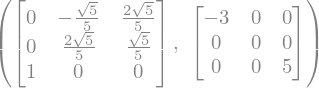

In [54]:
P, D = T.diagonalize(normalize=True)
P, D

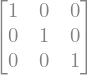

In [55]:
sp.simplify(P.T*P)  # orthonormal columns: P is orthogonal, so P^t P = I

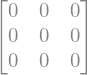

In [56]:
sp.simplify(P*D*P.T - T)  # and therefore T = P D P^t

**Why we care:** symmetric matrices like this one are exactly what the stress tensor and the strain-rate tensor $S_{ij}$ (see the [kinematics and the material derivative](../kinematics_material_derivative.ipynb) notebook) look like. Their eigenvectors give the _principal axes_ (the directions in which the flow is purely stretching with no shear), and their eigenvalues give the principal stresses/rates. So this problem is a rehearsal.

# PROBLEM 6: ORDINARY DIFFERENTIAL EQUATIONS (ODEs)

## Problem statement

(a) When computing streamlines of a flow field in the $(x,y)$ plane, we are faced with the ODE $\frac{dy}{dx} = c x y$ for some suitable dimensional constant $c$. Classify this ODE.

(b) Solve $\frac{dy}{dx} = x y$ for $y(x)$ subject to $y(0)=y_0$.

(c) When considering how a rocket in horizontal motion, position $x(t)$, is slowed down by air drag, we are faced with the ODE $\frac{d^2 x}{dt^2} = -k\left(\frac{dx}{dt}\right)^2$ for some suitable dimensional constant $k$. Classify this ODE.

(d) Solve $\frac{d^2 x}{dt^2} = -k\left(\frac{dx}{dt}\right)^2$ for $x(t)$ subject to $x(0)=0$ and $\frac{dx}{dt}(t=0)=v_0$.

(e) Sketch, diagram, or plot the solution from (d) for a few values of $k$ and $v_0$ of your choosing.

(f) Consider the ODE $\frac{df}{dt} + a(t) f = b(t)$. Classify this ODE. (On your own: how would you find the solution $f(t)$, given $f(0) = f_0$ and arbitrary $a(t)$ and $b(t)$?)

(g) When studying simple harmonic motion, we are faced with the ODE $f'' +  c_2 f = c_3$, where $c_2$ and $c_3$ are constants. Classify this ODE.

(h) Find the general solution $f(t)$ of the ODE $f'' + c_2 f = c_3$ (no need to apply initial conditions, since I haven't given you any).

## Solution

On the classification parts (a), (c), (f), (g), terminology varies across textbooks, and it is your reasoning that matters, so no computer is going to fill in those tables for you. But SymPy _can_ corroborate your thinking: [`ode_order`](https://docs.sympy.org/latest/modules/solvers/ode.html#sympy.solvers.deutils.ode_order) reports the order, and [`classify_ode`](https://docs.sympy.org/latest/modules/solvers/ode.html#sympy.solvers.ode.classify_ode) lists every solution method it recognizes for the equation. Names such as `separable` and `1st_linear` in that list are direct evidence for the "separable" and "linear" boxes.

Read that list as "methods that _apply_," though, not as a set of mutually exclusive labels. A linear ODE is also a (degenerate) `Bernoulli` equation, for instance, so both hints show up for the same equation. Use it as evidence, not as an oracle.

Three cautions, which are themselves good illustrations of the convention ambiguity the problem set warns you about:

* **A missing `separable` only means something for a first-order ODE.** SymPy does not test separability at all above first order, so parts (c) and (g) show no `separable` hint no matter what. That happens to line up with our tables (which treat separability as a first-order notion), but it is agreement by luck, not evidence.
* **The word `homogeneous` means two different things inside SymPy's own hint names.** In `nth_linear_constant_coeff_homogeneous` it means what our table means: zero right-hand side. But in `1st_homogeneous_coeff_best` (and its relatives) it means something else entirely: that $dy/dx$ can be written as a function of $y/x$ alone. That is a substitution method, not a statement about the right-hand side. Never tick the "homogeneous" box just because you saw the word.
* **Silence is not disagreement.** For a _first-order_ equation, SymPy's hints draw no distinction at all between homogeneous and inhomogeneous, or between constant- and variable-coefficient. So on parts (a) and (f), two of the five rows simply get no comment from the computer. Those rows are yours.

### (a)

Write the ODE in the standard form "everything on the left, zero on the right," $\frac{dy}{dx} - cxy = 0$, and let SymPy have a look.

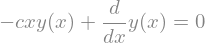

In [57]:
x, c = sp.symbols('x c')
y = sp.Function('y')(x)

ODE = sp.Eq(y.diff(x) - c*x*y, 0)
ODE  # to print it, so we can check it

In [58]:
sp.ode_order(ODE, y)

In [59]:
sp.classify_ode(ODE, y)

('separable',
 '1st_exact',
 '1st_linear',
 'Bernoulli',
 'almost_linear',
 '1st_power_series',
 'lie_group',
 'separable_Integral',
 '1st_exact_Integral',
 '1st_linear_Integral',
 'Bernoulli_Integral',
 'almost_linear_Integral')

First-order ✔, `separable` ✔, `1st_linear` ✔: three of our five rows corroborated. The hints ending in `_Integral` are just the same methods with the integrals left unevaluated.

The other two rows are the "silence is not disagreement" case above: the equation _is_ homogeneous (the right-hand side is zero) and it _does_ have the variable coefficient $cx$ multiplying $y$, but nothing in this hint list says so either way. You fill those in by looking at the equation.

### (b)

Now we solve, using SymPy's [`dsolve`](https://docs.sympy.org/dev/guides/solving/solve-ode.html), with the initial condition passed through `ics`. (Take $c=1$, as the problem asks.)

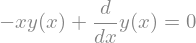

In [60]:
x = sp.symbols('x')
y0 = sp.symbols('y0')
y = sp.Function('y')(x)

dydx = y.diff(x)

# this is the ODE we will solve
ODE = sp.Eq(dydx - x*y, 0)
ODE  # to print it, so we can check it

In [61]:
solution = sp.dsolve(ODE, y, ics={y.subs(x, 0): y0})
solution  # to print the solution

So $y(x) = y_0 e^{x^2/2}$, matching the by-hand separation of variables. Since these are streamlines, note that $y$ never changes sign: a streamline cannot cross the line $y=0$, which is itself a streamline.

### (c)

Again, standard form first: $\frac{d^2x}{dt^2} + k\left(\frac{dx}{dt}\right)^2 = 0$.

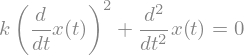

In [62]:
t, k, v0 = sp.symbols('t k v0')
x = sp.Function('x')(t)

ODE = sp.Eq(x.diff(t, 2) + k*x.diff(t)**2, 0)
ODE  # to print it, so we can check it

In [63]:
sp.ode_order(ODE, x)

In [64]:
sp.classify_ode(ODE, x)

('factorable', 'Liouville', 'nth_order_reducible', 'Liouville_Integral')

Second-order ✔. Note what is _missing_ from the list: no `1st_linear`, no `nth_linear_...` hint anywhere, because the $(dx/dt)^2$ term makes this ODE **nonlinear**. (The missing `separable` is _not_ evidence here, per the first caution above; that box we fill in ourselves, on the grounds that separability is a first-order notion.)

What _is_ in the list is `nth_order_reducible`, and that is precisely the hint given in the problem: the unknown $x$ itself never appears, only its derivatives, so substituting $u=dx/dt$ reduces the second-order ODE to a first-order one for $u(t)$. The classifier found the same trick you were asked to find. 🙂

We can watch that happen. Write down the reduced equation, $\frac{du}{dt} = -ku^2$, and classify _it_:

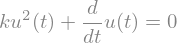

In [65]:
u = sp.Function('u')(t)

# what x'' + k(x')^2 = 0 becomes after substituting u = dx/dt
reduced_ODE = sp.Eq(u.diff(t) + k*u**2, 0)
reduced_ODE

In [66]:
sp.classify_ode(reduced_ODE, u)

('separable',
 '1st_exact',
 'Bernoulli',
 '1st_rational_riccati',
 'Riccati_special_minus2',
 '1st_power_series',
 'lie_group',
 'separable_Integral',
 '1st_exact_Integral',
 'Bernoulli_Integral')

`separable` ✔, and it is genuinely first-order now, so this time the hint means what we want it to mean. Be precise about what that buys us, though: the equation we were _given_ is not separable (the "nonseparable" box refers to the second-order equation as it stands), but the first-order equation hiding inside it is, and that is what makes the by-hand solution in part (d) possible.

### (d)

We could follow the reduction by hand, but `dsolve` will take the second-order ODE with both initial conditions directly. Note how the initial condition on the derivative is expressed with `dxdt.subs(t, 0)`.

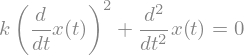

In [67]:
t = sp.symbols('t')
k = sp.symbols('k')
v0 = sp.symbols('v0')
x = sp.Function('x')(t)

dxdt = x.diff(t)
d2xdt2 = dxdt.diff(t)

# this is the ODE we will solve
ODE = sp.Eq(d2xdt2 + k*(dxdt)**2, 0)
ODE  # to print it, so we can check it

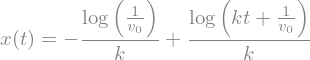

In [68]:
solution = sp.dsolve(ODE, x, ics={x.subs(t, 0): 0, dxdt.subs(t, 0): v0})
solution  # to print the solution

And we can use the SymPy `simplify` command (also implemented as an object property function) to try to make it look nicer.

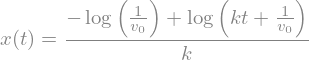

In [69]:
solution.simplify()

It didn't help much since it is conservative on how it simplifies logarithms.

We would've needed to tell it that $t>0$ (time is positive), the drag coefficient $k>0$ and the initial motion (and velocity) to the right, $v_0>0$. So, we can redo the solution as:

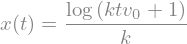

In [70]:
t = sp.symbols('t', positive=True)
k = sp.symbols('k', positive=True)
v0 = sp.symbols('v0', positive=True)
x = sp.Function('x')(t)
xprime = x.diff(t)
xdoubleprime = xprime.diff(t)
ODE = xdoubleprime + k*(xprime)**2
solution = sp.dsolve(ODE, x, ics={x.subs(t, 0): 0, xprime.subs(t, 0): v0})
solution.simplify()

That's better! This is the by-hand answer, $x(t) = \frac{\ln(kv_0t+1)}{k}$.

Being explicit about assumptions is not a SymPy quirk, by the way. It is the same physical reasoning that lets you drop absolute values around logarithms when you separate variables on paper.

### (e)

To plot the solution, we need to convert the SymPy symbolic expression for $x(t)$ into a form that NumPy can evaluate numerically. We use [lambdify](https://docs.sympy.org/latest/modules/utilities/lambdify.html) and build in the parameters $k$ and $v_0$ as inputs of the evaluated function, in addition to $t$.

Keep in mind that 'solution' is an equation (as seen above), so we use the 'rhs' attribute to grab the right-hand side.

In [71]:
xoft = sp.lambdify((t, k, v0), solution.rhs)

In [72]:
# check a value to make sure it works,
# so, evaluate x(t) for t=1, k=0.1, and v0=1.3
xoft(t=1, k=0.1, v0=1.3)

Define a function to make a plot of $x(t)$, given $k$ and $v_0$.

In [73]:
def plot_func(k, v0):
    tplot = np.linspace(0, 10, num=100)
    xplot = xoft(tplot, k, v0)

    fig, ax = plt.subplots(tight_layout=True)
    ax.set_ylabel('$x(t)$')
    ax.set_xlabel('$t$')

    ax.plot(tplot, xplot, linewidth=2)

    ax.grid(alpha=0.5, linestyle='dotted')

    ax.set_xlim(tplot.min(), tplot.max())
    ax.set_ylim(bottom=0)

    plt.show()

Test it out for $k=1$ and $v_0=1$.

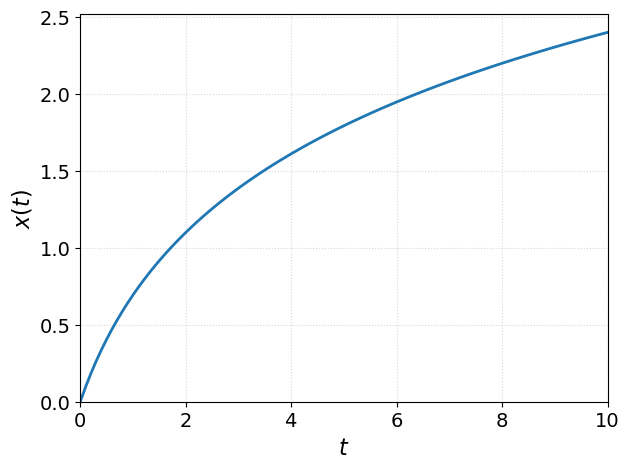

In [74]:
plot_func(1, 1)

Now, make an [interactive](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html) plot to play with $k$ and $v_0$. (To move the sliders, you need to open the notebook on Colab, or download the notebook in your own local Python environment, and execute all the cells up to this point.)

In [75]:
interact(plot_func,
         k=widgets.FloatSlider(min=0.01, max=5, step=0.1, description='Drag coeff. k'),
         v0=widgets.FloatSlider(min=1, max=10, step=0.5, description='Init. vel. v_0'));

Make a combination plot for several $k$ and $v_0$ of my choosing, using some fun [colors from Matplotlib](https://matplotlib.org/stable/gallery/color/named_colors.html) to group the curves by $k$ value visually.

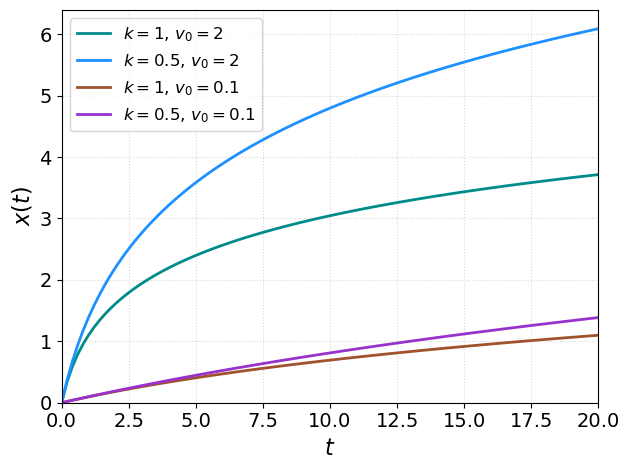

In [76]:
tplot = np.linspace(0, 20, num=100)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel('$x(t)$')
ax.set_xlabel('$t$')

ax.plot(tplot, xoft(tplot, 1, 2),
        linewidth=2, color='darkcyan', label=r'$k=1$, $v_0=2$')
ax.plot(tplot, xoft(tplot, 0.5, 2),
        linewidth=2, color='dodgerblue', label=r'$k=0.5$, $v_0=2$')

ax.plot(tplot, xoft(tplot, 1, 0.1),
        linewidth=2, color='sienna', label=r'$k=1$, $v_0=0.1$')
ax.plot(tplot, xoft(tplot, 0.5, 0.1),
        linewidth=2, color='darkorchid', label=r'$k=0.5$, $v_0=0.1$')

ax.grid(alpha=0.5, linestyle='dotted')

ax.set_xlim(tplot.min(), tplot.max())
ax.set_ylim(bottom=0)

ax.legend();

# to save the plot as a PDF
# fig.savefig("Prob6e_plot.pdf")
# to and download the file on colab
# files.download("Prob6e_plot.pdf")

Large $k$ means larger drag, and the rocket doesn't go as far, $x(t)$ remains small.

A larger initial velocity $v_0$ sends it farther, but eventually the drag slows it down.

To see how it slows down, we could plot the velocity, $v(t) = dx/dt$ too. We observe it always decays to 0, but how fast it decays depends on $k$ and $v_0$.

In [77]:
voft = sp.lambdify((t, k, v0), solution.rhs.diff(t))

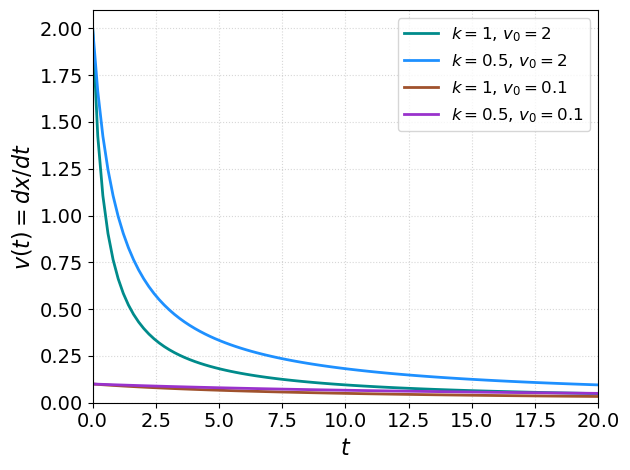

In [78]:
tplot = np.linspace(0, 20, num=100)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel('$v(t) = dx/dt$')
ax.set_xlabel('$t$')

ax.plot(tplot, voft(tplot, 1, 2),
        linewidth=2, color='darkcyan', label=r'$k=1$, $v_0=2$')
ax.plot(tplot, voft(tplot, 0.5, 2),
        linewidth=2, color='dodgerblue', label=r'$k=0.5$, $v_0=2$')

ax.plot(tplot, voft(tplot, 1, 0.1),
        linewidth=2, color='sienna', label=r'$k=1$, $v_0=0.1$')
ax.plot(tplot, voft(tplot, 0.5, 0.1),
        linewidth=2, color='darkorchid', label=r'$k=0.5$, $v_0=0.1$')

ax.grid(alpha=0.5, linestyle='dotted')

ax.set_xlim(tplot.min(), tplot.max())
ax.set_ylim(bottom=0)

ax.legend();

Note that $x(t)\sim\ln t$ grows without bound, slowly, even though $v(t)\to0$: with _quadratic_ drag only, the rocket never quite stops. That is a genuine (and initially surprising) feature of the model, not a numerical artifact &mdash; a good example of why we look at the formula _and_ the picture.

### (f)

Standard form: $\frac{df}{dt} + a(t)f - b(t) = 0$, with $a(t)$ and $b(t)$ arbitrary, so again we use undefined functions.

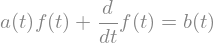

In [79]:
t = sp.symbols('t', positive=True)
f0 = sp.symbols('f0', positive=True)
f = sp.Function('f')(t)
a = sp.Function('a')(t)
b = sp.Function('b')(t)

dfdt = f.diff(t)

# this is the the ODE we will solve
ODE = sp.Eq(dfdt + a*f, b)
ODE  # to print it, so we can check it

In [80]:
sp.ode_order(ODE, f)

In [81]:
sp.classify_ode(ODE, f)

('1st_exact',
 '1st_linear',
 'Bernoulli',
 'almost_linear',
 '1st_power_series',
 'lie_group',
 '1st_exact_Integral',
 '1st_linear_Integral',
 'Bernoulli_Integral',
 'almost_linear_Integral')

First-order ✔ and `1st_linear` ✔. The homogeneity and coefficient rows are again SymPy's blind spot, so you fill those in yourself by inspection: variable coefficient $a(t)$, and inhomogeneous because $b(t)\neq0$.

This time, though, `separable` is _absent_ from the list, and since this equation really is first-order, that absence is real evidence, not the artifact it was in part (c). A general $b(t)$ spoils separability, even though the ODE is perfectly linear. Separable and linear are independent properties!

Although the problem set only asks you to classify this one, we may as well solve it. Sometimes it helps to give SymPy [hints](https://docs.sympy.org/latest/modules/solvers/ode.html#sympy.solvers.ode.single.FirstLinear) for solving ODEs.

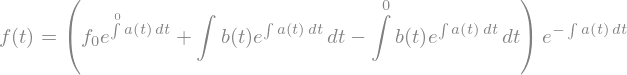

In [82]:
solution = sp.dsolve(
    ODE, f, ics={f.subs(t, 0): f0}, hint='1st_linear_Integral')
solution.simplify()  # to print the solution

The solution looks a little weird because $\int$ is the indefinite integral and $\int\limits_{}^{0}$ is the indefinite integral evaluated at $t=0$.

Written out in the usual way, this is the integrating-factor solution
$$f(t) = e^{-\int_0^t a(\tilde{t})\,d\tilde{t}}\left[f_0 + \int_0^t b(\tilde{s})\,e^{\int_0^{\tilde{s}} a(\tilde{t})\,d\tilde{t}}\,d\tilde{s}\right].$$

### (g)

Standard form: $f'' + c_2 f - c_3 = 0$, with $c_2$ and $c_3$ constants.

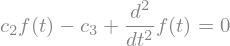

In [83]:
t = sp.symbols('t', positive=True)
c2 = sp.symbols('c2')
c3 = sp.symbols('c3')
f = sp.Function('f')(t)

fprime = f.diff(t)
fprimeprime = fprime.diff(t)

# this is the ODE we will solve
ODE = sp.Eq(fprimeprime + c2*f - c3, 0)
ODE  # to print it, so we can check it

In [84]:
sp.ode_order(ODE, f)

In [85]:
sp.classify_ode(ODE, f)

('nth_linear_constant_coeff_undetermined_coefficients',
 'nth_linear_constant_coeff_variation_of_parameters',
 'nth_linear_constant_coeff_variation_of_parameters_Integral',
 '2nd_nonlinear_autonomous_conserved',
 '2nd_nonlinear_autonomous_conserved_Integral')

Second-order ✔, and the hint names say it all: `nth_linear_constant_coeff_undetermined_coefficients`, so linear ✔ and constant-coefficient ✔. This is the one classification part where SymPy comments on _four_ of the five rows, because for a linear equation of order $\geq2$ it bothers to name the coefficient type.

Don't be thrown by `2nd_nonlinear_autonomous_conserved` further down the list: that is the method for the _general_ autonomous equation $f''=g(f)$, which of course includes our linear $g(f) = c_3-c_2f$ as a special case. It says the method applies, not that our ODE is nonlinear. (This is exactly the "methods, not labels" caveat from above.)

And the homogeneity row, the one SymPy stayed quiet about in parts (a) and (f), we can get at here by asking the question twice. Set the right-hand side to zero and watch the hint names change:

In [86]:
sp.classify_ode(sp.Eq(fprimeprime + c2*f, 0), f)  # same ODE, but with c3 = 0

('nth_linear_constant_coeff_homogeneous',
 '2nd_power_series_ordinary',
 '2nd_nonlinear_autonomous_conserved',
 '2nd_nonlinear_autonomous_conserved_Integral')

With $c_3=0$ we get `nth_linear_constant_coeff_homogeneous`, and here `homogeneous` does mean what our table means: a zero right-hand side. Restore $c_3\neq0$ and that hint is replaced by `undetermined_coefficients` and `variation_of_parameters`, which are the two standard methods for _inhomogeneous_ problems. So this row genuinely is corroborated: **inhomogeneous** ✔.

Compare that with `1st_homogeneous_coeff_best`, the other use of the word from the cautions above, and you can see why reading hint names as classification labels is a trap. Same word, two unrelated meanings, in the same list of names.

### (h)

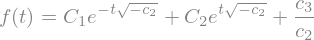

In [87]:
solution = sp.dsolve(ODE, f)
solution  # to print the solution

This is the by-hand answer,
$$f(t) = \underbrace{C_1e^{\sqrt{-c_2}\,t} + C_2e^{-\sqrt{-c_2}\,t}}_{f_h(t),\ \text{homogeneous}} + \underbrace{\frac{c_3}{c_2}}_{F_p(t),\ \text{particular}},$$
with `C1` and `C2` the two constants of integration that initial conditions (not given) would fix.

The hint in the problem set asks you to treat $c_2>0$, $c_2<0$, and $c_2=0$ separately, and this is where telling SymPy what we know pays off again. The three cases are the _same_ formula wearing different clothes, so let's redo the solution three times, changing only how we declare $c_2$.

First, $c_2>0$ (simple harmonic motion):

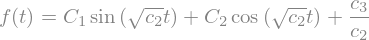

In [88]:
c2 = sp.symbols('c2', positive=True)

ODE = sp.Eq(f.diff(t, 2) + c2*f - c3, 0)
sp.dsolve(ODE, f)

[Euler's formula](https://en.wikipedia.org/wiki/Euler%27s_formula) has turned the complex exponentials into $\cos(\sqrt{c_2}\,t)$ and $\sin(\sqrt{c_2}\,t)$: oscillations, with the particular solution $c_3/c_2$ shifting the equilibrium position.

Next, $c_2<0$:

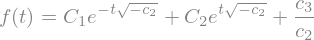

In [89]:
c2 = sp.symbols('c2', negative=True)

ODE = sp.Eq(f.diff(t, 2) + c2*f - c3, 0)
sp.dsolve(ODE, f)

Now $\sqrt{-c_2}$ is real, so the solution grows/decays exponentially (equivalently, in terms of $\cosh$ and $\sinh$). This is the unstable case, and it is exactly the structure we will meet when we look for growing disturbances in a flow.

Finally, $c_2=0$, which we impose by simply putting a zero where $c_2$ used to be:

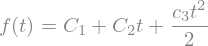

In [90]:
ODE = sp.Eq(f.diff(t, 2) + 0*f - c3, 0)
sp.dsolve(ODE, f)

The ODE has degenerated to $f''=c_3$, which we just integrate twice to get $f(t) = \tfrac{1}{2}c_3t^2 + C_1t + C_2$. Note that the $c_3/c_2$ particular solution blew up in this limit, so this case genuinely has to be treated separately, and the computer only said so once we told it that $c_2=0$.

**On your own:** verify (with Euler's formula, and the definitions of $\cosh$ and $\sinh$ in terms of exponentials) that you can write the constants of the trigonometric and hyperbolic forms in terms of the $C_1$ and $C_2$ of the general exponential form.

# FINAL REMARKS

What the computer did here was the _algebra_. What it could not do was decide that an arbitrary function of $y$ belongs in Problem 3, that $t$ is independent of $(x,y,z)$ in Problem 1, that $k>0$ and $v_0>0$ in Problem 6, or that a rescaled eigenvector in Problem 5 is the same answer as yours. Those are the modeling decisions, and they are yours to make.

So use these tools the way I do: work the problem by hand first, then come here to check it and to play with the answer &mdash; plot it, take limits, push the parameters around. That last part is where the physical intuition actually comes from.

If you found yourself surprised by any of the manipulations above, that is useful information. It tells you the prerequisite topic(s) you need to review, which was the whole point of this problem set. Potter & Feeny's textbook is a good place to start, and the problem set itself links to specific 3Blue1Brown, Khan Academy, and MIT OCW videos for some topics.